# combine master files

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [1]:
# Install a pip package in the current Jupyter kernel
import importlib, sys, subprocess
print(f"sys.executable: {sys.executable}")
!{sys.executable} -m pip install numpy==1.22 pillow==8.4 matplotlib==3.2

packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"**** {pkg} module is now installed.")
    else: 
        print(f"******** {pkg} module is already installed.")
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")


sys.executable: /home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/bin/python
  Using cached numpy-1.22.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached Pillow-8.4.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
  Using cached matplotlib-3.2.0-cp38-cp38-manylinux1_x86_64.whl (12.4 MB)
  Attempting uninstall: pillow
    Found existing installation: Pillow 9.4.0
    Uninstalling Pillow-9.4.0:
      Successfully uninstalled Pillow-9.4.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.1
    Uninstalling numpy-1.24.1:
      Successfully uninstalled numpy-1.24.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.6.3
    Uninstalling matplotlib-3.6.3:
      Successfully uninstalled matplotlib-3.6.3
******** numpy module is already installed.
******** pandas module is already installed.
******** matplotlib module is already installed.
******** scipy module is already installed.
***

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

### import modules

In [3]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import astropy.units as u
from astropy.stats import sigma_clip
from ccdproc import combine, ccd_process, CCDData

import ysfitsutilpy as yfu
import ysphotutilpy as ypu
import ysvisutilpy as yvu

import _astro_utilities
import _Python_utilities

In [12]:
#%%
BASEDIR = Path("/mnt/Rdata/CCD_obs") 
#BASEDIR = Path("/mnt/OBS_data") 
DOINGDIR = Path(BASEDIR/ "RnE_2022/GSON300_STF-8300M")
#DOINGDIR = Path(BASEDIR/ "CCD_new_files1")

#DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
#print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

len(DOINGDIRs):  18


In [40]:
for DOINGDIR in DOINGDIRs[:1] :
    #DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)
    fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(fits_in_dir))

    if len(fits_in_dir) == 0 :
        print(f"There is no fits fils in {DOINGDIR}")
        pass
    else : 
        print(f"Starting: {str(DOINGDIR.parts[-1])}")
    
        MASTERDIR = DOINGDIR / _astro_utilities.master_dir

        if not MASTERDIR.exists():
            os.makedirs("{}".format(str(MASTERDIR)))
            print("{} is created...".format(str(MASTERDIR)))

        fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
        #print("fits_in_dir", fits_in_dir)
        print("len(fits_in_dir)", len(fits_in_dir))

        if len(fits_in_dir) == 0 :
            print(f"There is no fits fils in {DOINGDIR}")
            pass
        else : 

            summary = yfu.make_summary(DOINGDIR/"*.fit*")
            #print(summary)
            print("len(summary):", len(summary))
            print("summary:", summary)
            #print(summary["file"][0])

DOINGDIR /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin
len(fits_in_dir) 263
Starting: KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin
len(fits_in_dir) 263
All 45 keywords (guessed from /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/-_BIAS_-_2022-10-09-11-02-32_1sec_-_STF-8300M_-20c_1bin.fit) will be loaded.


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key FOCNAME not found for /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/-_BIAS_-_2022-10-26-13-29-51_1sec_-_STF-8300M_17c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key FOCPOS not found for /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/-_BIAS_-_2022-10-26-13-29-51_1sec_-_STF-8300M_17c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key FOCUSPOS not found for /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-83

len(summary): 263
summary:                                                   file  filesize  SIMPLE  \
0    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16980480    True   
1    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16980480    True   
2    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16980480    True   
3    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16980480    True   
4    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16980480    True   
..                                                 ...       ...     ...   
258  /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16983360    True   
259  /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16983360    True   
260  /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16983360    True   
261  /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16983360    True   
262  /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...  16983360    True   

     BITPIX  NAXIS  NAXIS1  NAXIS2 EXTEND    BZERO IMAGETYP 

### BIAS

In [41]:
#bias_fits = summary[summary["IMAGETYP"] == "BIAS"]["file"]
bias_fits = summary.loc[summary["IMAGETYP"] == "BIAS"].copy()
bias_fits.reset_index(inplace=True)
bias_fits = bias_fits["file"]
print(type(bias_fits))
print(len(bias_fits))
print(bias_fits)

bias_comb = yfu.group_combine(
                bias_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["BIAS"],
                group_key = ["EXPTIME"],
                fmt = "master_bias.fits",  # output file name format
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose = True
            )

<class 'pandas.core.series.Series'>
40
0     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
1     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
2     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
3     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
4     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
5     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
6     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
7     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
8     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
9     /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
10    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
11    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
12    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
13    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
14    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
15    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
16    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
17    /mn

/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/imutil/imcombine.py:159: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for g_val, group in gs:


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_bias.fits will be overridden.
.................................(dt = 21.541 s) 2023-04-12T10:47:09.837


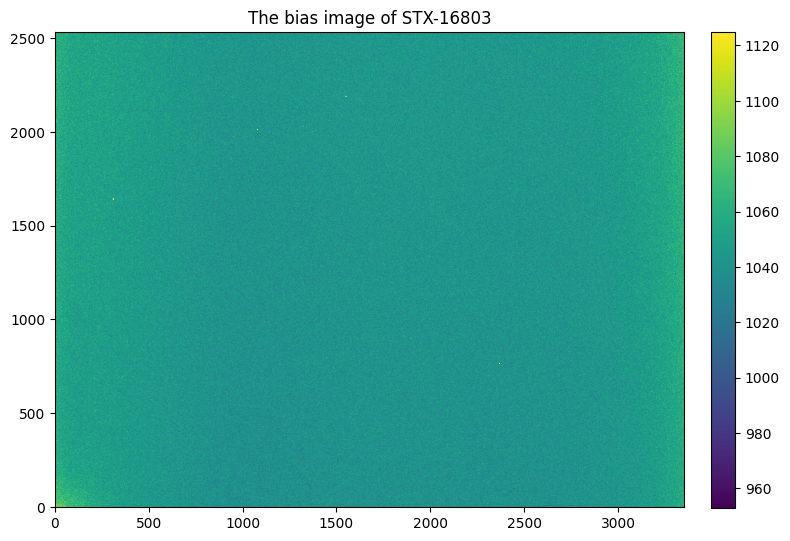

In [42]:
import matplotlib.pyplot as plt
from astropy.io import fits
hdul = fits.open(bias_fits[0])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The bias image of STX-16803')
plt.colorbar(im, fraction=0.035, pad=0.04)
plt.tight_layout()

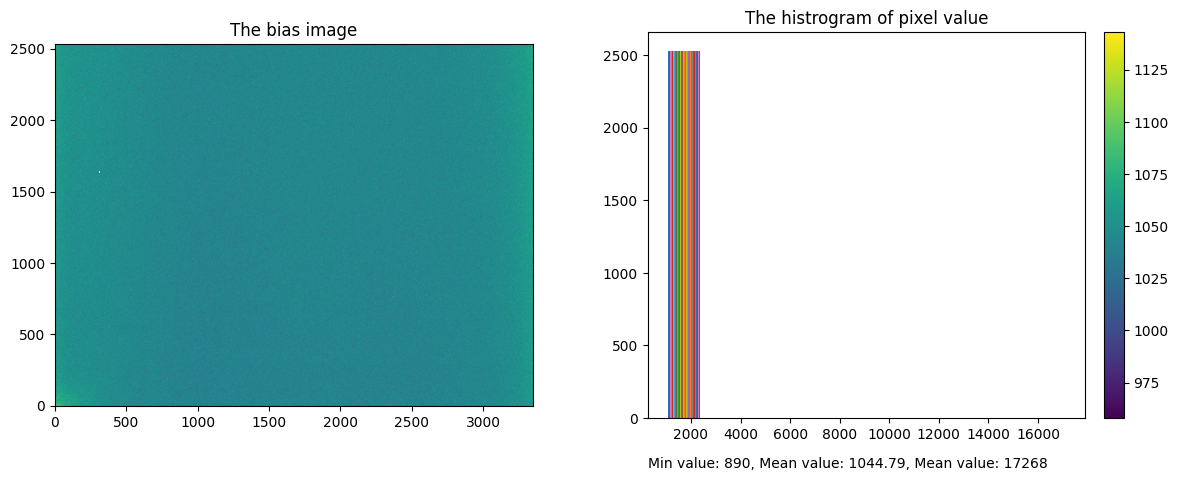

In [43]:
hdul = fits.open(bias_fits[12])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The bias image')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

### DARK

In [44]:
#dark_fits = summary[summary["IMAGETYP"] == "DARK"]["file"]
dark_fits = summary.loc[summary["IMAGETYP"] == "DARK"].copy()
dark_fits.reset_index(inplace=True)
dark_fits = dark_fits["file"]
print(type(dark_fits))
print(len(dark_fits))
print(dark_fits)
# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
dark_comb = yfu.group_combine(
                dark_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["DARK"],
                group_key = ["EXPTIME"],
                fmt = "master_dark_{:.0f}sec.fits",  # output file name format
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose = True
            )

<class 'pandas.core.series.Series'>
130
0      /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
1      /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
2      /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
3      /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
4      /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
                             ...                        
125    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
126    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
127    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
128    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
129    /mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/...
Name: file, Length: 130, dtype: object
Group and combine by ['EXPTIME'] (total 4 groups)
* 100.0... (20 files)


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/imutil/imcombine.py:159: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for g_val, group in gs:


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_dark_100sec.fits will be overridden.
* 120.0... (20 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_dark_120sec.fits will be overridden.
* 180.0... (20 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_dark_180sec.fits will be overridden.
* 240.0... (20 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_dark_240sec.fits
.................................(dt = 49.958 s) 2023-04-12T10:48:20.926


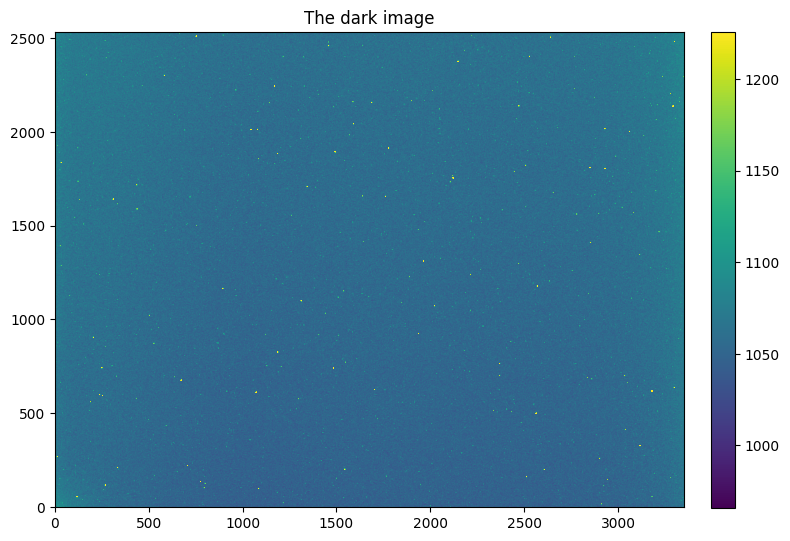

In [45]:
hdul = fits.open(dark_fits[2])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The dark image')
plt.colorbar(im, fraction=0.035, pad=0.04)
plt.tight_layout()


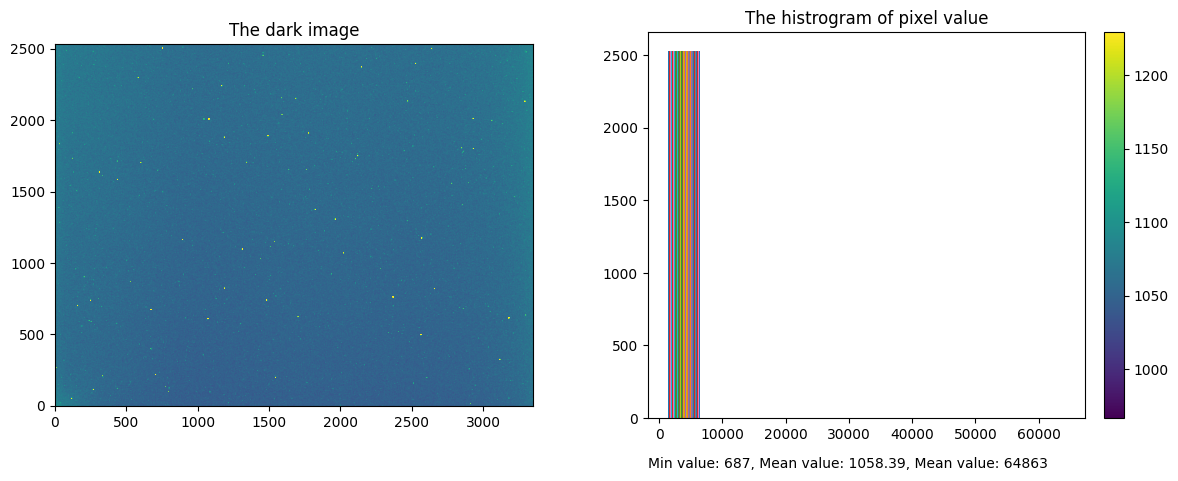

In [29]:
hdul = fits.open(dark_fits[5])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The dark image')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.035, pad=0.04)
plt.tight_layout(pad=5.0)

## Flat

In [34]:
flat_fits = summary[summary["IMAGETYP"] == "FLAT"]["file"] 
# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
flat_comb_norm = yfu.group_combine(
                flat_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["FLAT"],
                group_key = ["FILTER"],
                fmt = "master_flat_{:s}_norm.fits",  # output file name format
                scale="med_sc", #norm
                scale_to_0th=False, #norm
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose=True
            )

# Say dark frames have header OBJECT = "calib" && "IMAGE-TYP" = "DARK"
flat_comb_norm = yfu.group_combine(
                flat_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["FLAT"],
                group_key = ["FILTER"],
                fmt = "master_flat_{:s}.fits",  # output file name format
                #scale="med_sc", #norm
                #scale_to_0th=False, #norm
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "med",
                memlimit = 2.e+10,
                verbose=True
            )

Group and combine by ['FILTER'] (total 3 groups)
* B... (16 files)


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/imutil/imcombine.py:159: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for g_val, group in gs:


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_B_norm.fits
* R... (16 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_R_norm.fits
* V... (16 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_V_norm.fits
.................................(dt = 43.236 s) 2023-04-12T10:29:13.074
Group and combine by ['FILTER'] (total 3 groups)
* B... (16 files)


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/ysfitsutilpy/imutil/imcombine.py:159: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for g_val, group in gs:


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_B.fits
* R... (16 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_R.fits
* V... (16 files)


	/mnt/Rdata/CCD_obs/RnE_2022/GSON300_STF-8300M/KLEOPATRA_Light_-_2022-10-23_-_GSON300_STF-8300M_-_1bin/master_files_ys/master_flat_V.fits
.................................(dt = 24.061 s) 2023-04-12T10:29:37.136


In [38]:
hdul = fits.open(flat_fits[3])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The flat image')
plt.colorbar(im, fraction=0.035, pad=0.04)
plt.tight_layout()

KeyError: 3

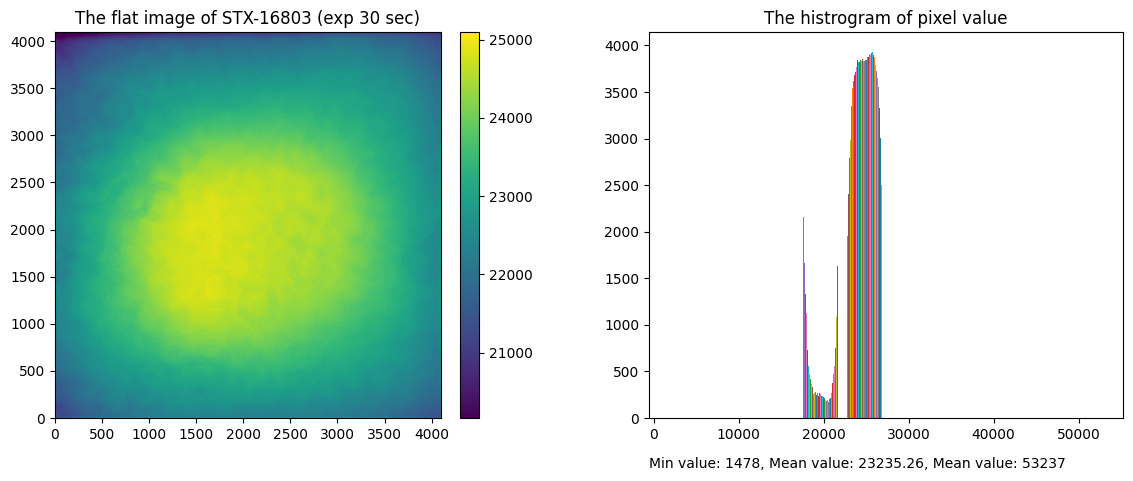

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.035, pad=0.04)
plt.tight_layout(pad=5.0)

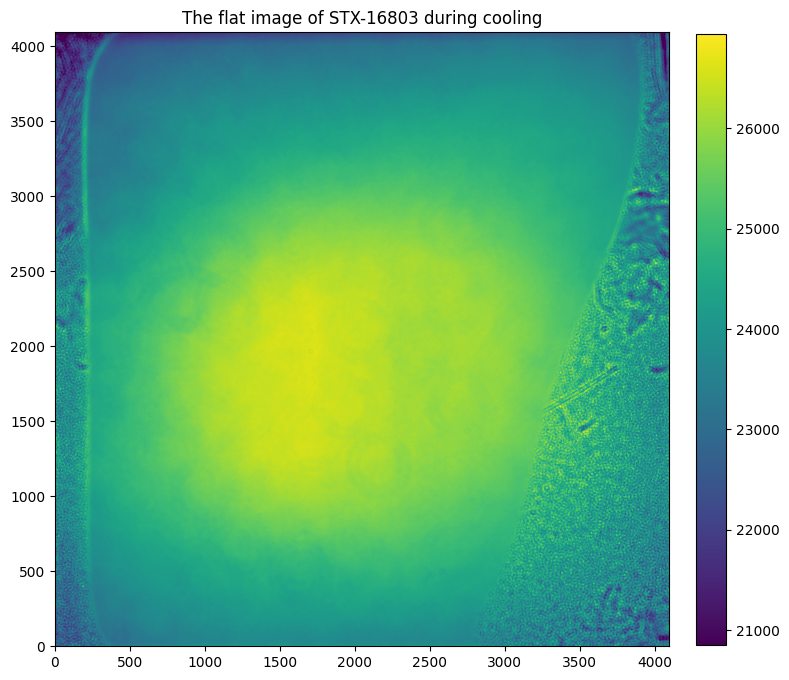

In [ ]:
hdul = fits.open(flat_fits[10])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The flat image')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

## Flat image

skyflat image

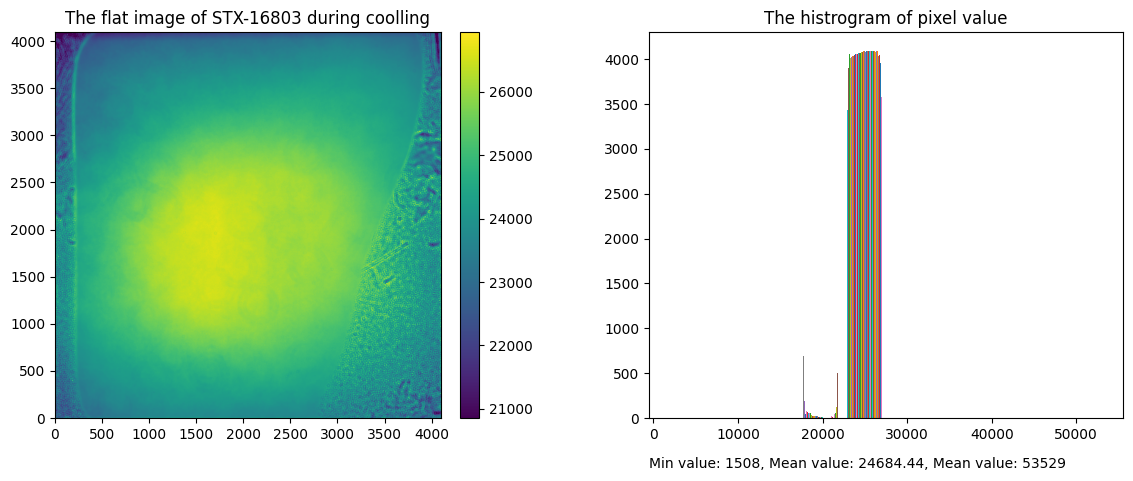

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803 during coolling')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)